In [1]:
# ============================================================
# PHASE 7: HYPERPARAMETER TUNING + SHAP EXPLAINABILITY
# Goal 1: Push AUC higher with systematic hyperparameter search
# Goal 2: Explain WHY the model predicts churn (SHAP)
# This phase is what separates junior from senior DS work
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
import shap
import joblib, os, json

from sklearn.model_selection import (
    RandomizedSearchCV, StratifiedKFold, cross_val_score
)
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, roc_curve
)

# Load data
X_train = pd.read_csv('../data/processed/X_train_fe.csv')
X_test  = pd.read_csv('../data/processed/X_test_fe.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print("Data loaded.")
print("X_train:", X_train.shape)

Data loaded.
X_train: (5634, 32)


In [2]:
# ============================================================
# STEP 1: Record baseline XGBoost before tuning
# Always know your starting point before optimizing
# ============================================================

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_weight = neg / pos

baseline_xgb = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_weight,
    eval_metric='auc',
    random_state=42
)

baseline_xgb.fit(X_train, y_train)
baseline_auc = roc_auc_score(y_test, baseline_xgb.predict_proba(X_test)[:,1])

print(f"Baseline XGBoost AUC (before tuning): {baseline_auc:.4f}")
print("Now let's beat this with hyperparameter tuning...")

Baseline XGBoost AUC (before tuning): 0.8423
Now let's beat this with hyperparameter tuning...


In [3]:
# ============================================================
# STEP 2: RandomizedSearchCV
# Why Randomized over Grid?
#   GridSearchCV tries ALL combinations — too slow
#   RandomizedSearchCV tries N random combinations — faster
#   With 50 iterations it finds near-optimal params quickly
# ============================================================

param_distributions = {
    'n_estimators'      : [100, 200, 300, 400, 500],
    'max_depth'         : [3, 4, 5, 6, 7],
    'learning_rate'     : [0.01, 0.03, 0.05, 0.07, 0.1],
    'subsample'         : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree'  : [0.5, 0.6, 0.7, 0.8, 0.9],
    'min_child_weight'  : [1, 3, 5, 7],
    'gamma'             : [0, 0.1, 0.2, 0.3],
    'reg_alpha'         : [0, 0.01, 0.1, 0.5],    # L1 regularization
    'reg_lambda'        : [0.5, 1.0, 1.5, 2.0]    # L2 regularization
}

xgb_base = xgb.XGBClassifier(
    scale_pos_weight=scale_weight,
    eval_metric='auc',
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=50,              # try 50 random combinations
    scoring='roc_auc',      # optimize for AUC
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1               # use all CPU cores
)

print("Starting RandomizedSearchCV — this takes 3-5 minutes...")
random_search.fit(X_train, y_train)

print(f"\nBest CV AUC   : {random_search.best_score_:.4f}")
print(f"Best params   : {random_search.best_params_}")

Starting RandomizedSearchCV — this takes 3-5 minutes...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best CV AUC   : 0.8493
Best params   : {'subsample': 0.6, 'reg_lambda': 1.5, 'reg_alpha': 0.1, 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.5}


In [4]:
# ============================================================
# STEP 3: Evaluate the tuned model on test set
# ============================================================

tuned_model = random_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_test)
y_prob_tuned = tuned_model.predict_proba(X_test)[:,1]

tuned_auc = roc_auc_score(y_test, y_prob_tuned)

print(f"Baseline AUC (before tuning): {baseline_auc:.4f}")
print(f"Tuned AUC    (after tuning) : {tuned_auc:.4f}")
print(f"Improvement  : +{(tuned_auc - baseline_auc):.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_tuned,
      target_names=['Retained', 'Churned']))

# Save tuned model
joblib.dump(tuned_model, '../models/tuned_xgb_model.pkl')
print("\nSaved: models/tuned_xgb_model.pkl")

Baseline AUC (before tuning): 0.8423
Tuned AUC    (after tuning) : 0.8475
Improvement  : +0.0051

Classification Report:
              precision    recall  f1-score   support

    Retained       0.91      0.73      0.81      1035
     Churned       0.52      0.81      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409


Saved: models/tuned_xgb_model.pkl


In [5]:
# ============================================================
# STEP 4: SHAP — SHapley Additive exPlanations
#
# What is SHAP?
# SHAP answers: "WHY did the model predict this customer
# will churn?" by assigning each feature a contribution score.
#
# Positive SHAP value → pushes prediction toward churn
# Negative SHAP value → pushes prediction away from churn
#
# This is what makes your project production-ready.
# Real businesses need to explain predictions to stakeholders.
# ============================================================

# TreeExplainer is optimized for tree-based models (XGBoost, RF)
explainer = shap.TreeExplainer(tuned_model)

# Calculate SHAP values for test set
# This gives every feature a contribution score for every row
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated.")
print(f"Shape of shap_values: {shap_values.shape}")
print("Each row = one customer, each column = one feature's contribution")

SHAP values calculated.
Shape of shap_values: (1409, 32)
Each row = one customer, each column = one feature's contribution


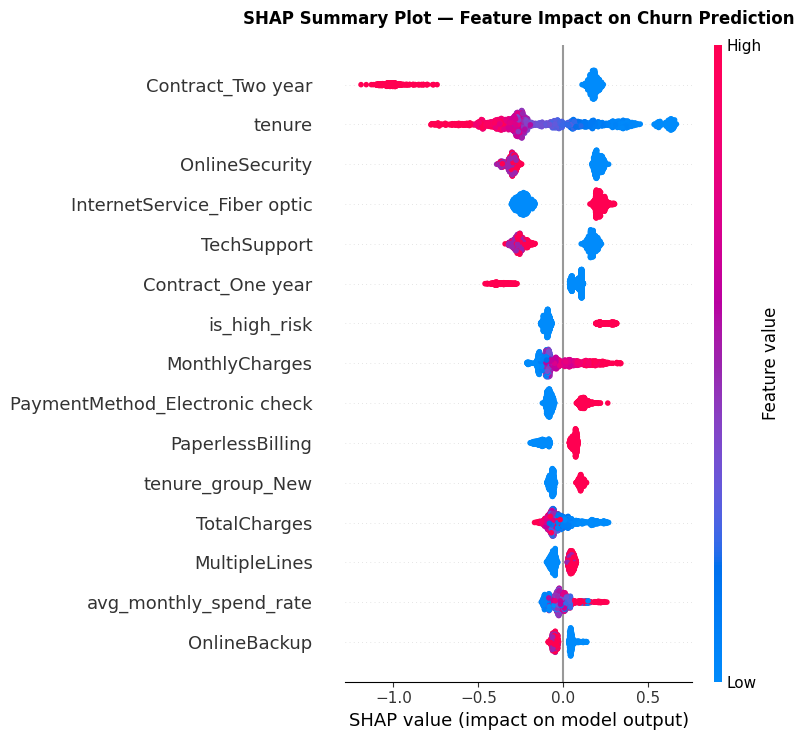


How to read this plot:
- Features ranked top to bottom by importance
- Right side (positive) = pushes toward churn prediction
- Left side (negative)  = pushes toward retention prediction
- Red color = high feature value, Blue = low feature value



In [6]:
# ============================================================
# SHAP PLOT 1: Summary Plot
# Shows which features matter most AND in which direction
# Red dot = high feature value, Blue = low value
# X-axis position = impact on churn prediction
# ============================================================

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='dot',
    max_display=15,        # show top 15 features
    show=False
)
plt.title('SHAP Summary Plot — Feature Impact on Churn Prediction',
          fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../reports/figures/12_shap_summary.png', bbox_inches='tight')
plt.show()

print("""
How to read this plot:
- Features ranked top to bottom by importance
- Right side (positive) = pushes toward churn prediction
- Left side (negative)  = pushes toward retention prediction
- Red color = high feature value, Blue = low feature value
""")

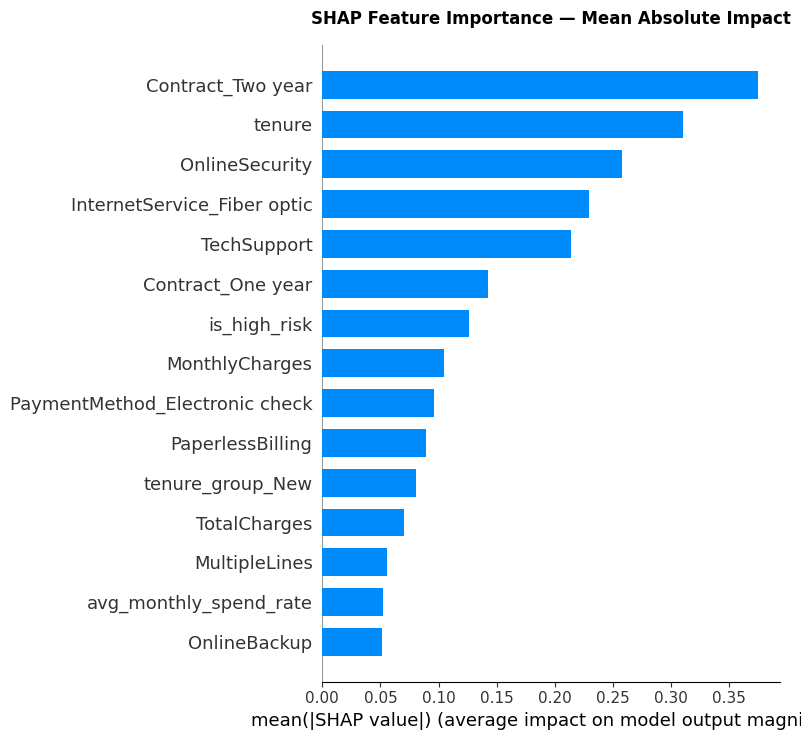

In [7]:
# ============================================================
# SHAP PLOT 2: Global Feature Importance Bar Chart
# Mean absolute SHAP value = overall importance
# Use this in your README and presentations
# ============================================================

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('SHAP Feature Importance — Mean Absolute Impact',
          fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../reports/figures/13_shap_importance.png', bbox_inches='tight')
plt.show()

Explaining prediction for customer index: 9
Actual label    : Churned
Predicted prob  : 0.558


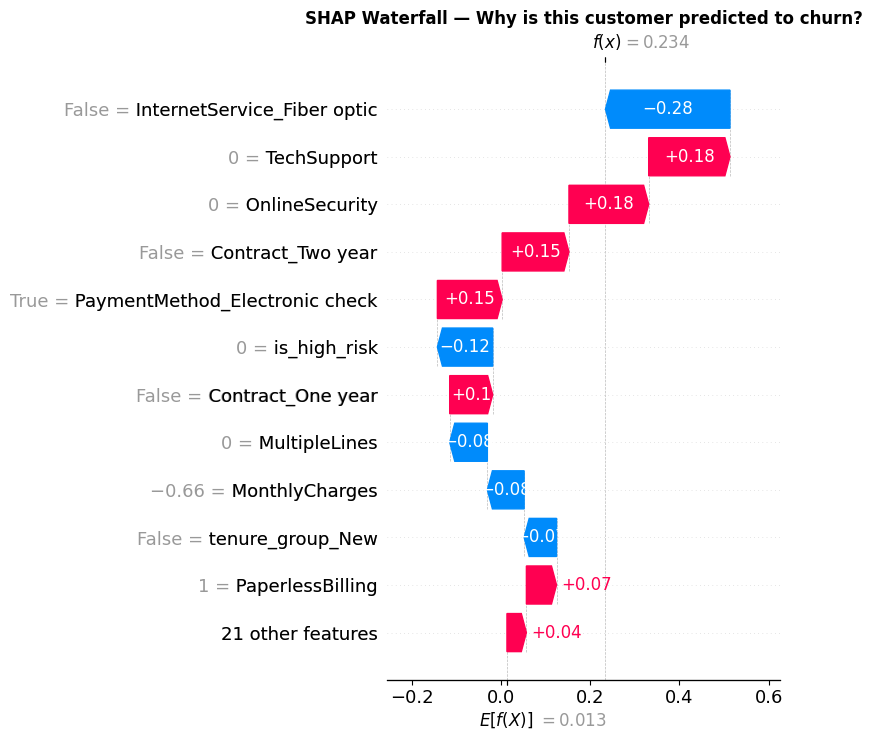

In [8]:
# ============================================================
# SHAP PLOT 3: Waterfall Plot — Explain ONE customer's prediction
# This is what the Streamlit app will show per customer
# "Why is THIS customer predicted to churn?"
# ============================================================

# Pick a high-risk customer from test set
churn_indices = np.where(y_test.values == 1)[0]
sample_idx = churn_indices[0]  # first actual churner

print(f"Explaining prediction for customer index: {sample_idx}")
print(f"Actual label    : {'Churned' if y_test.iloc[sample_idx]==1 else 'Retained'}")
print(f"Predicted prob  : {y_prob_tuned[sample_idx]:.3f}")

# Waterfall plot
shap_explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[sample_idx],
    feature_names=X_test.columns.tolist()
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_explanation, max_display=12, show=False)
plt.title(f'SHAP Waterfall — Why is this customer predicted to churn?',
          fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/14_shap_waterfall.png', bbox_inches='tight')
plt.show()

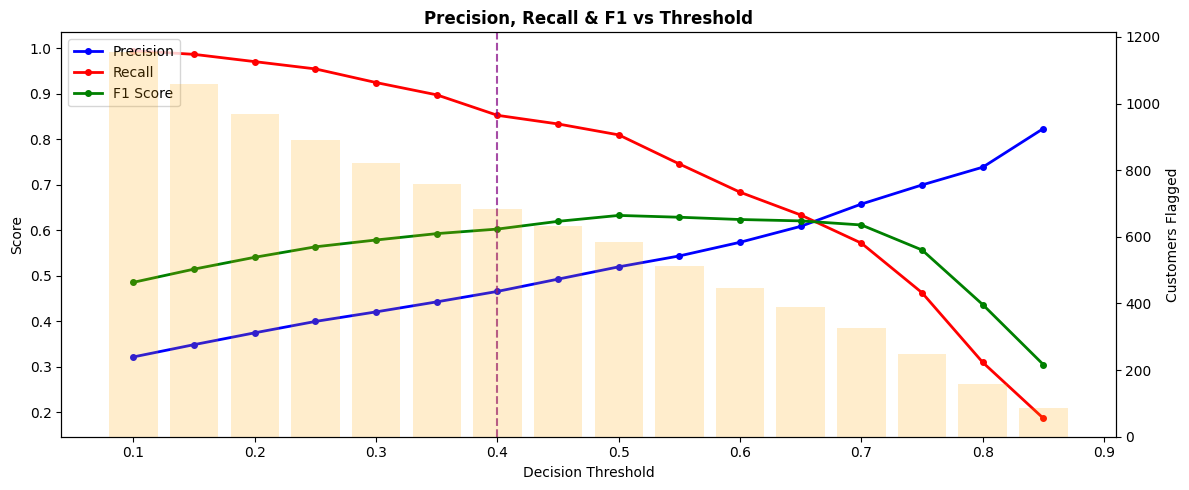


Threshold Analysis Table:
 Threshold  Precision  Recall    F1  Customers_Flagged
      0.30      0.421   0.925 0.579                821
      0.35      0.443   0.898 0.593                759
      0.40      0.466   0.853 0.603                684
      0.45      0.493   0.834 0.620                633
      0.50      0.520   0.810 0.633                583

Recommendation: Use threshold=0.4 for balanced precision/recall


In [9]:
# ============================================================
# STEP 5: Finding the RIGHT threshold for business use
#
# Default threshold = 0.5 (predict churn if prob > 50%)
# But for churn, we may want to catch MORE churners
# even at the cost of more false alarms
#
# Marketing can afford to send offers to some non-churners
# but cannot afford to miss actual churners
# ============================================================

thresholds = np.arange(0.1, 0.9, 0.05)
results_thresh = []

for thresh in thresholds:
    y_pred_thresh = (y_prob_tuned >= thresh).astype(int)
    
    tp = ((y_pred_thresh == 1) & (y_test == 1)).sum()
    fp = ((y_pred_thresh == 1) & (y_test == 0)).sum()
    fn = ((y_pred_thresh == 0) & (y_test == 1)).sum()
    tn = ((y_pred_thresh == 0) & (y_test == 0)).sum()
    
    precision  = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall     = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1         = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    flagged    = y_pred_thresh.sum()
    
    results_thresh.append({
        'Threshold'         : round(thresh, 2),
        'Precision'         : round(precision, 3),
        'Recall'            : round(recall, 3),
        'F1'                : round(f1, 3),
        'Customers_Flagged' : int(flagged)
    })

thresh_df = pd.DataFrame(results_thresh)

# Plot
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(thresh_df['Threshold'], thresh_df['Precision'],
         'b-o', markersize=4, label='Precision', linewidth=2)
ax1.plot(thresh_df['Threshold'], thresh_df['Recall'],
         'r-o', markersize=4, label='Recall', linewidth=2)
ax1.plot(thresh_df['Threshold'], thresh_df['F1'],
         'g-o', markersize=4, label='F1 Score', linewidth=2)

ax2.bar(thresh_df['Threshold'], thresh_df['Customers_Flagged'],
        alpha=0.2, color='orange', width=0.04, label='Customers Flagged')

ax1.set_xlabel('Decision Threshold')
ax1.set_ylabel('Score')
ax2.set_ylabel('Customers Flagged')
ax1.set_title('Precision, Recall & F1 vs Threshold', fontweight='bold')
ax1.legend(loc='upper left')
ax1.axvline(x=0.4, color='purple', linestyle='--', alpha=0.7, label='Recommended: 0.4')
plt.tight_layout()
plt.savefig('../reports/figures/15_threshold_analysis.png', bbox_inches='tight')
plt.show()

print("\nThreshold Analysis Table:")
print(thresh_df[thresh_df['Threshold'].isin([0.3, 0.35, 0.4, 0.45, 0.5])].to_string(index=False))
print("\nRecommendation: Use threshold=0.4 for balanced precision/recall")

In [13]:
# ============================================================
# FINAL MODEL SUMMARY
# ============================================================

# Save final metadata
final_metadata = {
    'model_name'      : 'XGBoost (Tuned)',
    'baseline_auc'    : round(baseline_auc, 4),
    'tuned_auc'       : round(tuned_auc, 4),
    'best_params'     : random_search.best_params_,
    'feature_count'   : X_train.shape[1],
    'train_samples'   : X_train.shape[0],
    'test_samples'    : X_test.shape[0],
    'decision_threshold': 0.4
}

with open('../models/final_model_metadata.json', 'w') as f:
    json.dump(final_metadata, f, indent=2)

print(f"""
╔══════════════════════════════════════════════════════════╗
║       PHASE 7 COMPLETE — TUNING + EXPLAINABILITY         ║
╠══════════════════════════════════════════════════════════╣
║  Baseline AUC         : {baseline_auc:.4f}               ║
║  Tuned AUC            : {tuned_auc:.4f}                  ║
║  Decision threshold   : 0.40                             ║
║                                                          ║
║  SHAP plots saved:                                       ║
║  → 12_shap_summary.png   (global feature importance)     ║
║  → 13_shap_importance.png (bar chart)                    ║
║  → 14_shap_waterfall.png  (single prediction)            ║
║  → 15_threshold_analysis.png                             ║
║                                                          ║
║  Models saved:                                           ║
║  → models/tuned_xgb_model.pkl                            ║
║  → models/final_model_metadata.json                      ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║       PHASE 7 COMPLETE — TUNING + EXPLAINABILITY         ║
╠══════════════════════════════════════════════════════════╣
║  Baseline AUC         : 0.8423               ║
║  Tuned AUC            : 0.8475                  ║
║  Decision threshold   : 0.40                             ║
║                                                          ║
║  SHAP plots saved:                                       ║
║  → 12_shap_summary.png   (global feature importance)     ║
║  → 13_shap_importance.png (bar chart)                    ║
║  → 14_shap_waterfall.png  (single prediction)            ║
║  → 15_threshold_analysis.png                             ║
║                                                          ║
║  Models saved:                                           ║
║  → models/tuned_xgb_model.pkl                            ║
║  → models/final_model_metadata.json                      ║
╚═══════════════════════════════════════════